# Eight-Hour NSW1 Electricity-Price Forecasting
## Seven-method A2 reproducibility notebook

> **Evidence boundary.** The default execution downloads and validates the public
> NSW1 dataset and compact archived-forecast evidence, reconstructs the frozen
> research protocol, and independently recalculates the reported metrics.

The complete model-specific preparation, training and inference paths are included
but disabled by default because they require different libraries and compute
environments. These paths were checked locally against the archived forecasts before
publication. The historical checkpoint revisions for Sundial and MOMENT were not
recorded, so a numerical match for those methods does not establish exact historical
checkpoint identity.

The notebook fails visibly if a public file, checksum, array identity, origin, shape
or frozen result differs from the approved evidence.


In [1]:
from __future__ import annotations

import gc
import hashlib
import importlib.metadata as metadata
import io
import json
import math
import platform
import sys
import tempfile
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EXECUTION_PROFILE = "metric_reproduction"  # default and only validated profile
OPTIONAL_MODEL = None  # arima | random_forest | lightgbm | dlinear | nhits | sundial | moment
OPTIONAL_RUN_KIND = "smoke"  # smoke | full_rerun; ignored by the validated default
EVIDENCE_BASE_URL = (
    "https://github.com/Yai-Git/nsw-electricity-price-forecasting-a2/releases/download/"
    "a2-evidence-v1"
)

PUBLIC_DATA_URL = (
    "https://github.com/Yai-Git/nsw-electricity-price-data-a2/releases/download/"
    "a2-data-v1/prices_NSW1_5min_prepared.csv"
)
PUBLIC_DATA_SIZE = 14_238_528
PUBLIC_DATA_SHA256 = "d9a3059fb517eabbdabfa2016b1195fef29eeff0bce00c0b60d7defeab0cddb7"
EVIDENCE_HASHES = {
    "a2_protocol.json": "1fad77ca43851f951ed8abd457beda943269a7318e262175dd1a0a6ad87bec26",
    "a2_archived_forecasts.npz": "720c0a9b0c0ce3bfbe0d2e13ec5f79afd48a76873ea0a3b585a13a2a0cf24b67",
    "a2_historical_timings.csv": "b85787b5fae487667443caa23f4c59caab9dd6e70fe6429e453f7481a3eca48e",
    "a2_evidence_manifest.json": "7688936cd1c16a7e83a758a04e213ff046f4523663feefcd6761190d489dc3a2",
}

MODEL_ORDER = [
    "seasonal_naive", "arima", "random_forest", "lightgbm",
    "dlinear", "nhits", "sundial", "moment",
]
DISPLAY_NAMES = {
    "seasonal_naive": "Daily seasonal naive",
    "arima": "ARIMA",
    "random_forest": "Random Forest",
    "lightgbm": "Quantile LightGBM",
    "dlinear": "DLinear",
    "nhits": "N-HiTS",
    "sundial": "Sundial",
    "moment": "MOMENT linear probe",
}

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()

def decoded_array_sha256(array: np.ndarray) -> str:
    return hashlib.sha256(np.ascontiguousarray(array).tobytes(order="C")).hexdigest()

def semantic_series_digest(timestamps: pd.Series, values: pd.Series) -> str:
    ts = pd.to_datetime(timestamps, errors="raise")
    assert ts.dt.tz is None
    records = np.empty(len(ts), dtype=np.dtype([("timestamp_ns", "<i8"), ("rrp", "<f8")]))
    records["timestamp_ns"] = ts.to_numpy(dtype="datetime64[ns]").astype("<i8", copy=False)
    records["rrp"] = values.to_numpy(dtype="<f8", copy=False)
    return decoded_array_sha256(records)

RUNTIME = tempfile.TemporaryDirectory(prefix="a2_research_staging_")
RUNTIME_DIR = Path(RUNTIME.name)

packages = ["numpy", "pandas", "matplotlib"]
version_rows = [{"package": "Python", "version": platform.python_version()}]
for package in packages:
    version_rows.append({"package": package, "version": metadata.version(package)})
versions = pd.DataFrame(version_rows)
print("Execution profile:", EXECUTION_PROFILE)
print("Runtime mode: portable temporary workspace with checksum-verified public inputs")
display(versions)


Execution profile: metric_reproduction
Runtime mode: portable temporary workspace with checksum-verified public inputs


,package,version
0,Python,3.12.7
1,numpy,1.26.4
2,pandas,2.2.3
3,matplotlib,3.9.2


## 1. Public data download and verification

The file is downloaded from the fixed `a2-data-v1` release. Size and SHA-256 are
checked before pandas is allowed to parse it. Timestamps remain timezone-naive and
are interpreted under the fixed NEM-time/AEST convention.


In [2]:
download_path = RUNTIME_DIR / "prices_NSW1_5min_prepared.csv"
request = urllib.request.Request(PUBLIC_DATA_URL, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(request, timeout=180) as response, download_path.open("wb") as handle:
    while chunk := response.read(1 << 20):
        handle.write(chunk)

assert download_path.stat().st_size == PUBLIC_DATA_SIZE
assert sha256_file(download_path) == PUBLIC_DATA_SHA256

EXPECTED_COLUMNS = [
    "date_time", "RRP", "RUNNO", "PERIODID", "PRICE_STATUS",
    "INVALIDFLAG", "continuity_segment_id",
]
public_frame = pd.read_csv(
    download_path,
    parse_dates=["date_time"],
    float_precision="round_trip",
)
assert public_frame.columns.tolist() == EXPECTED_COLUMNS
assert len(public_frame) == 348_371
assert public_frame["date_time"].dt.tz is None
assert public_frame["date_time"].is_monotonic_increasing
assert not public_frame.isna().any().any()
assert set(public_frame["REGIONID"].unique()) == {"NSW1"} if "REGIONID" in public_frame else True
assert set(public_frame["INVALIDFLAG"].unique()) == {0}

deltas = np.diff(public_frame["date_time"].to_numpy(dtype="datetime64[ns]"))
five_minutes = np.timedelta64(5, "m")
non_five = deltas[deltas != five_minutes]
non_five_minutes = (non_five / np.timedelta64(1, "m")).astype(np.int64)
assert sorted(non_five_minutes.tolist()) == [30, 35]
assert int(sum(int(delta / five_minutes) - 1 for delta in non_five)) == 11

dataset_summary = pd.DataFrame([{
    "rows": len(public_frame),
    "start": public_frame["date_time"].iloc[0],
    "end": public_frame["date_time"].iloc[-1],
    "minimum_RRP": public_frame["RRP"].min(),
    "median_RRP": public_frame["RRP"].median(),
    "mean_RRP": public_frame["RRP"].mean(),
    "maximum_RRP": public_frame["RRP"].max(),
    "non_five_minute_transitions": len(non_five),
    "missing_five_minute_timestamps": 11,
    "sha256": sha256_file(download_path),
}])
display(dataset_summary)


,rows,start,end,minimum_RRP,median_RRP,mean_RRP,maximum_RRP,non_five_minute_transitions,missing_five_minute_timestamps,sha256
0,348371,2021-10-01 00:05:00,2025-01-22 15:50:00,-1000.0,88.88,130.048609,17500.0,2,11,d9a3059fb517eabbdabfa2016b1195fef29eeff0bce00c...


## 2. Compact archived-evidence verification

The compact evidence bundle is downloaded from the fixed `a2-evidence-v1` release.
Every file is checked against its frozen SHA-256 value before any archived forecast
is loaded, and every decoded array is then checked against the manifest.


In [3]:
evidence_dir = RUNTIME_DIR / "evidence"
evidence_dir.mkdir()
for filename in EVIDENCE_HASHES:
    request = urllib.request.Request(
        f"{EVIDENCE_BASE_URL.rstrip('/')}/{filename}",
        headers={"User-Agent": "Mozilla/5.0"},
    )
    with urllib.request.urlopen(request, timeout=180) as response, (evidence_dir / filename).open("wb") as handle:
        while chunk := response.read(1 << 20):
            handle.write(chunk)
evidence_source = "public fixed evidence release"

for filename, expected_hash in EVIDENCE_HASHES.items():
    observed = sha256_file(evidence_dir / filename)
    if observed != expected_hash:
        raise RuntimeError(f"Evidence checksum mismatch for {filename}: {observed}")

protocol = json.loads((evidence_dir / "a2_protocol.json").read_text(encoding="utf-8"))
manifest = json.loads((evidence_dir / "a2_evidence_manifest.json").read_text(encoding="utf-8"))
timings = pd.read_csv(evidence_dir / "a2_historical_timings.csv")
evidence = np.load(evidence_dir / "a2_archived_forecasts.npz", allow_pickle=False)

assert protocol["status"] == "PUBLIC_ARCHIVED_METRIC_EVIDENCE"
assert manifest["publication_authority"] == "CONFIRMED_BY_STUDENT_2026-10-01"
assert manifest["contains_model_weights"] is False
assert manifest["contains_fitted_objects"] is False
for key, specification in manifest["arrays"].items():
    value = evidence[key]
    assert list(value.shape) == specification["shape"]
    assert value.dtype.str == specification["dtype"]
    assert decoded_array_sha256(value) == specification["decoded_sha256"]
    assert np.isfinite(value).all()

print("Evidence source:", evidence_source)
print("Manifest SHA-256:", sha256_file(evidence_dir / "a2_evidence_manifest.json"))
display(timings[["display_name", "regime", "train_s", "load_s", "infer_s", "run_total_s", "source"]])


Evidence source: public fixed evidence release
Manifest SHA-256: 7688936cd1c16a7e83a758a04e213ff046f4523663feefcd6761190d489dc3a2


,display_name,regime,train_s,load_s,infer_s,run_total_s,source
0,ARIMA,statistical,0.0,NaN,3.30,3.7,rerun 2026-07-27
1,DLinear,trained,3.0,NaN,0.02,7.8,rerun 2026-07-27
2,Quantile LightGBM,trained,2423.1,NaN,NaN,2425.1,rerun 2026-07-27 (orig log 2503.6)
3,MOMENT linear probe,trained,4349.0,71.3,3.00,79.9,train from orig log; inference rerun
4,N-HiTS,trained,5.2,NaN,0.10,6.7,rerun 2026-07-27
5,Random Forest,trained,420.4,NaN,0.10,422.2,rerun 2026-07-27 (orig log 463.4)
6,Sundial,zero-shot,0.0,4.0,10.30,19.3,rerun 2026-07-27


## 3. Reconstructing the frozen research series and protocol

The public assignment dataset begins at 00:05. The research protocol contains one
additional verified row at 00:00. The notebook reconstructs that row explicitly and
validates semantic digests before applying the frozen research indices.


In [4]:
public_prices = public_frame[["date_time", "RRP"]].copy()
assert semantic_series_digest(public_prices["date_time"], public_prices["RRP"]) == protocol["public_dataset"]["semantic_digest"]

first_row = pd.DataFrame({
    "date_time": [pd.Timestamp(protocol["research_series"]["first_timestamp"])],
    "RRP": [protocol["research_series"]["first_rrp"]],
})
research_frame = pd.concat([first_row, public_prices], ignore_index=True)
assert len(research_frame) == 348_372
assert semantic_series_digest(research_frame["date_time"], research_frame["RRP"]) == protocol["research_series"]["semantic_digest"]
assert np.array_equal(
    research_frame.iloc[1:]["date_time"].to_numpy(dtype="datetime64[ns]"),
    public_prices["date_time"].to_numpy(dtype="datetime64[ns]"),
)
assert np.array_equal(
    research_frame.iloc[1:]["RRP"].to_numpy(dtype=np.float64),
    public_prices["RRP"].to_numpy(dtype=np.float64),
)

research_origins = evidence["research_origin_indices"].astype(np.int64)
public_origins = evidence["public_origin_indices"].astype(np.int64)
origin_ns = evidence["origin_timestamp_ns"].astype("datetime64[ns]")
assert np.array_equal(public_origins, research_origins - 1)
assert len(research_origins) == 24
assert str(origin_ns[0]) == "2024-05-25T17:45:00.000000000"
assert str(origin_ns[-1]) == "2025-01-22T07:55:00.000000000"

rrp = research_frame["RRP"].to_numpy(dtype=np.float64)
targets = np.stack([rrp[o:o + 96] for o in research_origins])
baseline = np.stack([rrp[o - 288:o - 288 + 96] for o in research_origins])
assert targets.shape == (24, 96) and targets.size == 2_304
assert np.array_equal(targets, evidence["targets"])
assert np.array_equal(baseline, evidence["seasonal_naive"])
for research_o, public_o in zip(research_origins, public_origins):
    assert research_o == public_o + 1
    assert np.array_equal(
        rrp[research_o:research_o + 96],
        public_prices["RRP"].to_numpy(dtype=np.float64)[public_o:public_o + 96],
    )

assert int(np.sum(targets >= 300.0)) == protocol["frozen_protocol"]["extreme_target_count"] == 1
observed_event_rate = 100.0 * float(np.mean(targets >= 300.0))
assert np.isclose(
    observed_event_rate,
    protocol["frozen_protocol"]["extreme_target_rate_percentage_points"],
    atol=1e-6,
    rtol=0.0,
)

protocol_summary = pd.DataFrame([{
    "research_rows": len(research_frame),
    "train_records": protocol["frozen_protocol"]["split"]["num_train"],
    "validation_records": protocol["frozen_protocol"]["split"]["num_vali"],
    "test_records": protocol["frozen_protocol"]["split"]["num_test"],
    "forecast_windows": len(research_origins),
    "targets_per_window": targets.shape[1],
    "target_observations": targets.size,
    "targets_at_or_above_300": int(np.sum(targets >= 300.0)),
}])
display(protocol_summary)


,research_rows,train_records,validation_records,test_records,forecast_windows,targets_per_window,target_observations,targets_at_or_above_300
0,348372,243860,34838,69674,24,96,2304,1


## 4. Leakage-safe preparation functions

The functions below implement the historical indexing contract. They establish
window counts, construct the daily seasonal baseline, produce the 219 tabular
features and create raw sequence inputs without using future targets.


In [5]:
HORIZON = 96
DAILY_PERIOD = 288
TABULAR_CONTEXT = 672
ARIMA_CONTEXT = 2016
MOMENT_CONTEXT = 512
LAST_GAP = max(protocol["frozen_protocol"]["gap_indices"])
NUM_TRAIN = protocol["frozen_protocol"]["split"]["num_train"]
TAIL_START = NUM_TRAIN + protocol["frozen_protocol"]["split"]["num_vali"]

LAGS = [1, 2, 3, 6, 12, 24, 48, 96, 144]
ROLL_WINDOWS = [12, 96, 288]

def build_window_origins(context_length, lo_start, target_end, stride, last_gap=LAST_GAP):
    origins = []
    origin = max(lo_start, last_gap + context_length + 1)
    while origin + HORIZON <= target_end:
        if origin - context_length >= 0:
            origins.append(origin)
        origin += stride
    return np.asarray(origins, dtype=np.int64)

def context_stats(series, origins, context_length=TABULAR_CONTEXT):
    blocks = np.stack([series[o-context_length:o] for o in origins])
    location = np.median(blocks, axis=1)
    q75, q25 = np.percentile(blocks, [75, 25], axis=1)
    scale = np.maximum((q75 - q25) / 1.349, 1.0)
    return location, scale

def tabular_features(series, dates, origins):
    origins = np.asarray(origins, dtype=np.int64)
    columns, types, names = [], [], []
    def add(name, values, kind):
        names.append(name); columns.append(np.asarray(values, dtype=np.float64)); types.append(kind)
    for lag in LAGS:
        add(f"lag{lag}", series[origins-lag], "loc")
    for tag, start in [("day1", 288), ("day2", 576)]:
        for horizon in range(96):
            add(f"{tag}_{horizon}", series[origins-start+horizon], "loc")
    for width in ROLL_WINDOWS:
        block = np.stack([series[o-width:o] for o in origins])
        add(f"rmean{width}", block.mean(axis=1), "loc")
        add(f"rstd{width}", block.std(axis=1), "scale")
        add(f"rmin{width}", block.min(axis=1), "loc")
        add(f"rmax{width}", block.max(axis=1), "loc")
    add("dod", series[origins-1] - series[origins-1-DAILY_PERIOD], "scale")
    add("slope96", (series[origins-1] - series[origins-96]) / 96.0, "scale")
    timestamps = pd.DatetimeIndex(dates[origins])
    slot = timestamps.hour.to_numpy() * 12 + timestamps.minute.to_numpy() // 5
    dow = timestamps.dayofweek.to_numpy()
    add("tod_sin", np.sin(2*np.pi*slot/288), "none")
    add("tod_cos", np.cos(2*np.pi*slot/288), "none")
    add("dow_sin", np.sin(2*np.pi*dow/7), "none")
    add("dow_cos", np.cos(2*np.pi*dow/7), "none")
    return np.column_stack(columns), types, names

def normalize_tabular(raw_features, types, location, scale):
    normalized = raw_features.copy()
    for column, kind in enumerate(types):
        if kind == "loc":
            normalized[:, column] = np.clip(
                (normalized[:, column] - location) / scale, -5.0, 5.0
            )
        elif kind == "scale":
            normalized[:, column] = np.clip(normalized[:, column] / scale, -5.0, 5.0)
    return normalized

def sequence_inputs(series, origins, context_length):
    result = np.stack([series[o-context_length:o] for o in origins]).astype(np.float32)
    assert result.shape == (len(origins), context_length)
    return result

train_672 = build_window_origins(TABULAR_CONTEXT, TABULAR_CONTEXT, NUM_TRAIN, 8)
validation_672 = build_window_origins(TABULAR_CONTEXT, NUM_TRAIN, TAIL_START, 16)
train_512 = build_window_origins(MOMENT_CONTEXT, MOMENT_CONTEXT, NUM_TRAIN, 8)
validation_512 = build_window_origins(MOMENT_CONTEXT, NUM_TRAIN, TAIL_START, 16)
assert (len(train_672), len(validation_672)) == (5_524, 2_172)
assert (len(train_512), len(validation_512)) == (5_544, 2_172)

representative = research_origins[[0, 11, 23]]
raw_X, normalization_types, feature_names = tabular_features(
    rrp, research_frame["date_time"].to_numpy(), representative
)
location, scale = context_stats(rrp, representative)
normalized_X = normalize_tabular(raw_X, normalization_types, location, scale)
assert raw_X.shape == normalized_X.shape == (3, 219)
assert len(feature_names) == len(set(feature_names)) == 219
assert np.isfinite(normalized_X).all()

for length in [ARIMA_CONTEXT, TABULAR_CONTEXT, MOMENT_CONTEXT]:
    contexts = sequence_inputs(rrp, research_origins, length)
    assert research_origins.min() - length > LAST_GAP
    assert all((o - 1) < o for o in research_origins)
    del contexts

preparation_summary = pd.DataFrame([
    {"model_group": "ARIMA", "context": 2016, "training_windows": "per-origin fitting", "validation_windows": "not applicable"},
    {"model_group": "Random Forest / LightGBM", "context": 672, "training_windows": len(train_672), "validation_windows": len(validation_672)},
    {"model_group": "DLinear / N-HiTS", "context": 672, "training_windows": len(train_672), "validation_windows": len(validation_672)},
    {"model_group": "Sundial", "context": 672, "training_windows": 0, "validation_windows": 0},
    {"model_group": "MOMENT linear probe", "context": 512, "training_windows": len(train_512), "validation_windows": len(validation_512)},
])
display(preparation_summary)


,model_group,context,training_windows,validation_windows
0,ARIMA,2016,per-origin fitting,not applicable
1,Random Forest / LightGBM,672,5524,2172
2,DLinear / N-HiTS,672,5524,2172
3,Sundial,672,0,0
4,MOMENT linear probe,512,5544,2172


## 5. Metric reproduction

Point scores use the same 2,304 target prices. Mean signed error is
`prediction − observation`: positive values indicate average overprediction.
CRPS is recalculated only where compatible archived probabilistic samples exist.


In [6]:
PRICE_ATOL = 0.01
PRICE_RTOL = 1e-8
SKILL_ATOL = 1e-5

def overall_point_metrics(prediction, truth, baseline_mae):
    error = np.asarray(prediction, dtype=np.float64) - np.asarray(truth, dtype=np.float64)
    mae = float(np.mean(np.abs(error)))
    return {
        "mae": mae,
        "rmse": float(np.sqrt(np.mean(np.square(error)))),
        "mean_signed_error": float(np.mean(error)),
        "mae_skill_fraction": float((baseline_mae - mae) / baseline_mae),
    }

def crps_ensemble(samples, actual):
    samples = np.asarray(samples, dtype=np.float64)
    actual = np.asarray(actual, dtype=np.float64)
    first = np.mean(np.abs(samples - actual[None, :]), axis=0)
    count = samples.shape[0]
    if count == 1:
        spread = np.zeros_like(first)
    else:
        pairwise = np.abs(samples[:, None, :] - samples[None, :, :])
        spread = pairwise.sum(axis=(0, 1)) / (count * (count - 1))
    return float(np.mean(first - 0.5 * spread))

predictions = {"seasonal_naive": baseline}
for slug in MODEL_ORDER[1:]:
    predictions[slug] = evidence[f"point__{slug}"]

baseline_mae = float(np.mean(np.abs(baseline - targets)))
overall_rows = []
window_rows = []
baseline_window_mae = np.mean(np.abs(baseline - targets), axis=1)
for slug in MODEL_ORDER:
    prediction = predictions[slug]
    metrics = overall_point_metrics(prediction, targets, baseline_mae)
    if slug in {"lightgbm", "sundial"}:
        crps_windows = np.asarray([
            crps_ensemble(evidence[f"samples__{slug}"][index], targets[index])
            for index in range(24)
        ])
        metrics["crps"] = float(crps_windows.mean())
    else:
        metrics["crps"] = metrics["mae"]
    overall_rows.append({"method_key": slug, "method": DISPLAY_NAMES[slug], **metrics})

    per_window = np.mean(np.abs(np.asarray(prediction, dtype=np.float64) - targets), axis=1)
    if slug != "seasonal_naive":
        summary = {
            "method_key": slug,
            "method": DISPLAY_NAMES[slug],
            "windows_beating_baseline": int(np.sum(per_window < baseline_window_mae)),
            "median_window_mae": float(np.median(per_window)),
            "median_paired_difference": float(np.median(per_window - baseline_window_mae)),
            "minimum_window_mae": float(per_window.min()),
            "maximum_window_mae": float(per_window.max()),
            "pooled_mae": float(per_window.mean()),
        }
        window_rows.append(summary)

overall_results = pd.DataFrame(overall_rows)
window_summary = pd.DataFrame(window_rows)

for row in overall_results.to_dict(orient="records"):
    expected = protocol["expected_overall_metrics"][row["method_key"]]
    for metric in ["mae", "rmse", "mean_signed_error", "crps"]:
        assert np.isclose(row[metric], expected[metric], atol=PRICE_ATOL, rtol=PRICE_RTOL)
    assert np.isclose(
        row["mae_skill_fraction"], expected["mae_skill_fraction"],
        atol=SKILL_ATOL, rtol=0.0,
    )

for row in window_summary.to_dict(orient="records"):
    expected = protocol["expected_per_window_summary"][row["method_key"]]
    assert row["windows_beating_baseline"] == expected["windows_beating_seasonal_naive"]
    for observed_name, expected_name in [
        ("median_window_mae", "median_window_mae"),
        ("median_paired_difference", "median_paired_mae_difference"),
        ("minimum_window_mae", "minimum_window_mae"),
        ("maximum_window_mae", "maximum_window_mae"),
        ("pooled_mae", "pooled_mae"),
    ]:
        assert np.isclose(row[observed_name], expected[expected_name], atol=PRICE_ATOL, rtol=PRICE_RTOL)

overall_display = overall_results.copy()
overall_display["MAE skill (%)"] = 100.0 * overall_display["mae_skill_fraction"]
overall_display = overall_display[["method", "mae", "rmse", "mean_signed_error", "crps", "MAE skill (%)"]]
overall_display.columns = ["Method", "MAE", "RMSE", "Mean signed error", "CRPS", "MAE skill (%)"]
display(overall_display.round(2))
display(window_summary.drop(columns="method_key").round(2))
print("All frozen metric and per-window assertions passed.")


,Method,MAE,RMSE,Mean signed error,CRPS,MAE skill (%)
0,Daily seasonal naive,45.87,297.34,2.27,45.87,0.00
1,ARIMA,43.86,296.89,-0.82,43.86,4.37
2,Random Forest,43.13,296.28,2.68,43.13,5.96
3,Quantile LightGBM,41.43,295.72,-1.41,31.96,9.68
4,DLinear,42.55,296.21,-4.96,42.55,7.23
5,N-HiTS,44.19,296.84,-6.10,44.19,3.66
6,Sundial,45.24,298.37,12.99,36.95,1.38
7,MOMENT linear probe,77.21,330.76,-15.16,77.21,-68.33


,method,windows_beating_baseline,median_window_mae,median_paired_difference,minimum_window_mae,maximum_window_mae,pooled_mae
0,ARIMA,13,37.09,-0.52,9.91,181.03,43.86
1,Random Forest,18,36.31,-4.98,10.26,178.31,43.13
2,Quantile LightGBM,17,33.81,-5.99,9.09,174.71,41.43
3,DLinear,16,33.78,-4.68,12.46,172.90,42.55
4,N-HiTS,14,34.97,-4.32,11.34,181.08,44.19
5,Sundial,17,31.23,-5.28,7.43,177.36,45.24
6,MOMENT linear probe,11,46.77,1.25,14.96,526.83,77.21


All frozen metric and per-window assertions passed.


## 6. Compact reproduced figures


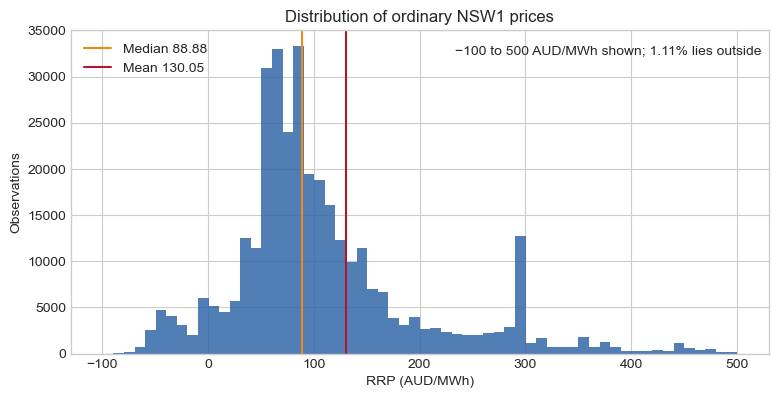

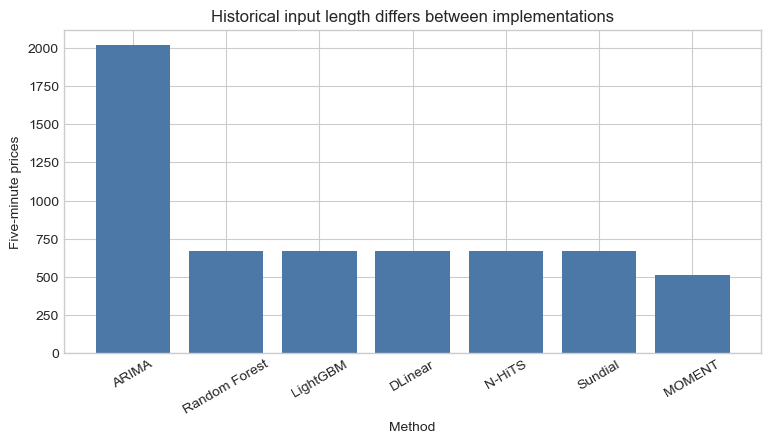

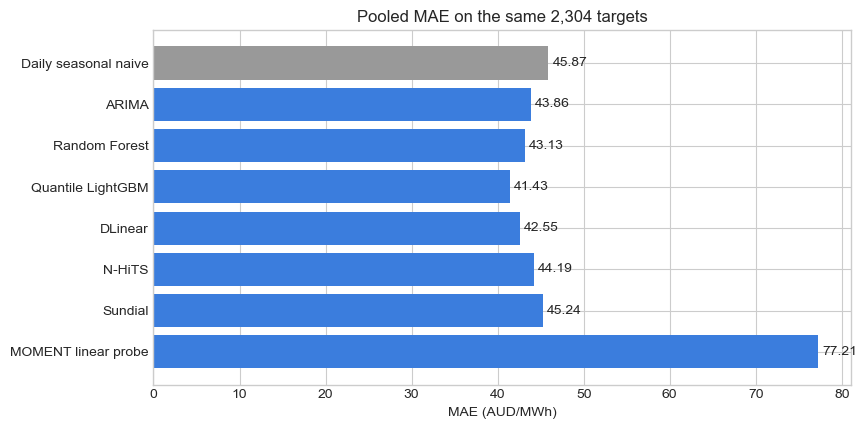

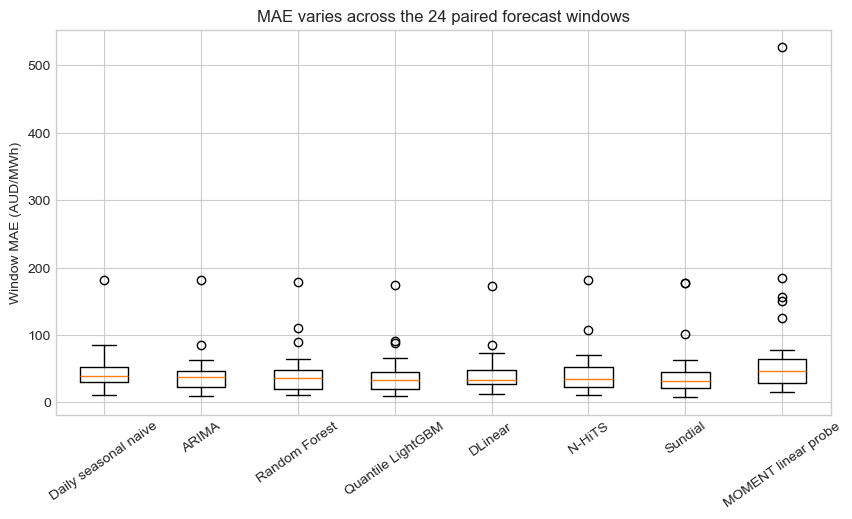

In [7]:
plt.style.use("seaborn-v0_8-whitegrid")

# Figure A: ordinary-price distribution.
central = research_frame.loc[research_frame["RRP"].between(-100, 500), "RRP"]
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(central, bins=60, color="#3267a8", alpha=0.85)
ax.axvline(research_frame["RRP"].median(), color="#ef8a17", label=f"Median {research_frame['RRP'].median():.2f}")
ax.axvline(research_frame["RRP"].mean(), color="#b2182b", label=f"Mean {research_frame['RRP'].mean():.2f}")
ax.set(title="Distribution of ordinary NSW1 prices", xlabel="RRP (AUD/MWh)", ylabel="Observations")
ax.text(0.99, 0.95, "−100 to 500 AUD/MWh shown; 1.11% lies outside", transform=ax.transAxes, ha="right", va="top")
ax.legend(); plt.show()

# Figure B: historical input lengths.
input_rows = [
    ("ARIMA", 2016), ("Random Forest", 672), ("LightGBM", 672),
    ("DLinear", 672), ("N-HiTS", 672), ("Sundial", 672), ("MOMENT", 512),
]
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar([row[0] for row in input_rows], [row[1] for row in input_rows], color="#4c78a8")
ax.set(title="Historical input length differs between implementations", ylabel="Five-minute prices", xlabel="Method")
ax.tick_params(axis="x", rotation=30); plt.show()

# Figure C: pooled point accuracy.
plot_overall = overall_results.copy()
fig, ax = plt.subplots(figsize=(9, 4.6))
colors = ["#999999" if key == "seasonal_naive" else "#3b7ddd" for key in plot_overall["method_key"]]
ax.barh(plot_overall["method"], plot_overall["mae"], color=colors)
ax.invert_yaxis(); ax.set(title="Pooled MAE on the same 2,304 targets", xlabel="MAE (AUD/MWh)")
for index, value in enumerate(plot_overall["mae"]):
    ax.text(value + 0.5, index, f"{value:.2f}", va="center")
plt.show()

# Figure D: per-window variability.
series = []
labels = []
for slug in MODEL_ORDER:
    series.append(np.mean(np.abs(np.asarray(predictions[slug], dtype=np.float64) - targets), axis=1))
    labels.append(DISPLAY_NAMES[slug])
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(series, tick_labels=labels, showfliers=True)
ax.set(title="MAE varies across the 24 paired forecast windows", ylabel="Window MAE (AUD/MWh)")
ax.tick_params(axis="x", rotation=35); plt.show()


## 7. Historical implementation code — optional profiles

These paths are excluded from the validated default execution. Use one profile per
fresh runtime. Package versions and hardware can alter results. Sundial and MOMENT
must not share a runtime because their recorded Transformers versions conflict.


In [8]:
# ARIMA optional full rerun: statsmodels 0.14.6, NumPy 1.26.4, SciPy 1.15.3.
def optional_arima_forecast(context, day_ago):
    from statsmodels.tsa.arima.model import ARIMA
    difference = context[288:] - context[:-288]
    fitted = ARIMA(difference, order=(2, 0, 1), trend="n").fit()
    return np.clip(np.asarray(fitted.forecast(96)) + day_ago, -1000.0, 17000.0)

if EXECUTION_PROFILE != "metric_reproduction" and OPTIONAL_MODEL == "arima":
    optional_predictions = []
    run_origins = research_origins[:1] if OPTIONAL_RUN_KIND == "smoke" else research_origins
    for origin in run_origins:
        context = rrp[origin-2016:origin]
        day_ago = rrp[origin-288:origin-192]
        optional_predictions.append(optional_arima_forecast(context, day_ago))
    optional_predictions = np.stack(optional_predictions)
    archived = predictions["arima"][:len(run_origins)]
    matched = np.allclose(optional_predictions, archived, atol=0.01, rtol=1e-8)
    status = (
        "CODE_PATH_SMOKE_PASSED" if OPTIONAL_RUN_KIND == "smoke" and matched
        else "CODE_PATH_SMOKE_DIFFERED" if OPTIONAL_RUN_KIND == "smoke"
        else "FULL_RERUN_MATCHED" if matched else "FULL_RERUN_DIFFERED"
    )
    print("ARIMA optional status:", status)
else:
    print("ARIMA optional path: NOT_RUN")


ARIMA optional path: NOT_RUN


In [9]:
# Random Forest / Quantile LightGBM optional implementation.
# Current executable preparation uses median/IQR; archived metadata says mean/std.
if EXECUTION_PROFILE != "metric_reproduction" and OPTIONAL_MODEL in {"random_forest", "lightgbm"}:
    from sklearn.ensemble import RandomForestRegressor
    tab_train = train_672[:400] if OPTIONAL_RUN_KIND == "smoke" else train_672
    tab_val = validation_672[:100] if OPTIONAL_RUN_KIND == "smoke" else validation_672
    tab_test = research_origins[:2] if OPTIONAL_RUN_KIND == "smoke" else research_origins
    train_raw, kinds, names = tabular_features(rrp, research_frame["date_time"].to_numpy(), tab_train)
    val_raw, _, _ = tabular_features(rrp, research_frame["date_time"].to_numpy(), tab_val)
    test_raw, _, _ = tabular_features(rrp, research_frame["date_time"].to_numpy(), tab_test)
    train_mu, train_scale = context_stats(rrp, tab_train)
    val_mu, val_scale = context_stats(rrp, tab_val)
    test_mu, test_scale = context_stats(rrp, tab_test)
    X_train = normalize_tabular(train_raw, kinds, train_mu, train_scale)
    X_val = normalize_tabular(val_raw, kinds, val_mu, val_scale)
    X_test = normalize_tabular(test_raw, kinds, test_mu, test_scale)
    Y_train_raw = np.stack([rrp[o:o+96] for o in tab_train])
    Y_val_raw = np.stack([rrp[o:o+96] for o in tab_val])
    Y_train = np.clip((Y_train_raw - train_mu[:, None]) / train_scale[:, None], -5, 5)
    Y_val = (Y_val_raw - val_mu[:, None]) / val_scale[:, None]
    if OPTIONAL_MODEL == "random_forest":
        grid = [
            {"max_depth": depth, "min_samples_leaf": leaf, "max_features": features}
            for depth in (None, 16) for leaf in (1, 5, 20) for features in ("sqrt", 1.0)
        ]
        if OPTIONAL_RUN_KIND == "smoke": grid = grid[:2]
        candidates = []
        for config in grid:
            fitted = RandomForestRegressor(
                n_estimators=300, random_state=42, n_jobs=-1, **config
            ).fit(X_train, Y_train)
            validation_raw = fitted.predict(X_val) * val_scale[:, None] + val_mu[:, None]
            candidates.append((float(np.mean(np.abs(validation_raw-Y_val_raw))), config, fitted))
        selected_mae, selected_config, selected_model = min(candidates, key=lambda item: item[0])
        optional_prediction = np.clip(
            selected_model.predict(X_test) * test_scale[:, None] + test_mu[:, None],
            -1000.0, 17000.0,
        )
        expected_config = {"max_depth": None, "min_samples_leaf": 1, "max_features": "sqrt"}
        if OPTIONAL_RUN_KIND == "full_rerun":
            assert selected_config == expected_config
            matched = np.allclose(optional_prediction, predictions["random_forest"], atol=0.01, rtol=1e-8)
            print("Random Forest status:", "FULL_RERUN_MATCHED" if matched else "FULL_RERUN_DIFFERED")
        else:
            print("Random Forest status: CODE_PATH_SMOKE_PASSED", selected_config, selected_mae)
    else:
        import lightgbm as lgb
        quantiles = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
        grid = [
            {"num_leaves": leaves, "min_child_samples": child}
            for leaves in (31, 63) for child in (20, 50)
        ]
        if OPTIONAL_RUN_KIND == "smoke": grid = grid[:1]
        horizon_subset = list(range(0, 96, 12)) if OPTIONAL_RUN_KIND == "full_rerun" else [0, 48, 95]
        def fit_boosters(config, objective, alpha, horizons):
            boosters = {}
            for horizon in horizons:
                estimator_config = dict(
                    objective=objective, learning_rate=0.05,
                    n_estimators=60 if OPTIONAL_RUN_KIND == "smoke" else 400,
                    num_threads=0, deterministic=True, force_row_wise=True,
                    random_state=42, verbose=-1, **config,
                )
                if alpha is not None:
                    estimator_config["alpha"] = alpha
                estimator = lgb.LGBMRegressor(**estimator_config)
                callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
                estimator.fit(
                    X_train, Y_train[:, horizon], eval_set=[(X_val, Y_val[:, horizon])],
                    eval_metric="quantile" if objective == "quantile" else "l1",
                    callbacks=callbacks,
                )
                boosters[horizon] = estimator
            return boosters
        selection = []
        for config in grid:
            boosters = fit_boosters(config, "regression_l1", None, horizon_subset)
            normalized = np.column_stack([boosters[h].predict(X_val) for h in horizon_subset])
            raw = normalized * val_scale[:, None] + val_mu[:, None]
            selection.append((float(np.mean(np.abs(raw-Y_val_raw[:, horizon_subset]))), config))
        _, selected = min(selection, key=lambda item: item[0])
        run_horizons = list(range(96)) if OPTIONAL_RUN_KIND == "full_rerun" else [0, 48, 95]
        quantile_predictions = {}
        for quantile in quantiles:
            boosters = fit_boosters(selected, "quantile", quantile, run_horizons)
            normalized = np.column_stack([boosters[h].predict(X_test) for h in run_horizons])
            quantile_predictions[quantile] = normalized * test_scale[:, None] + test_mu[:, None]
        if OPTIONAL_RUN_KIND == "full_rerun":
            point = np.clip(quantile_predictions[0.5], -1000.0, 17000.0)
            matched = np.allclose(point, predictions["lightgbm"], atol=0.01, rtol=1e-8)
            print("LightGBM status:", "FULL_RERUN_MATCHED" if matched else "FULL_RERUN_DIFFERED")
        else:
            print("LightGBM status: CODE_PATH_SMOKE_PASSED", selected, run_horizons)
else:
    print("Tabular optional paths: NOT_RUN")


Tabular optional paths: NOT_RUN


In [10]:
# DLinear / N-HiTS optional implementation, matching the executable source.
if EXECUTION_PROFILE != "metric_reproduction" and OPTIONAL_MODEL in {"dlinear", "nhits"}:
    import torch
    from torch import nn
    import torch.nn.functional as F

    class MovingAverage(nn.Module):
        def __init__(self, kernel):
            super().__init__(); self.kernel = kernel
        def forward(self, x):
            pad = (self.kernel - 1) // 2
            padded = nn.functional.pad(x.unsqueeze(1), (pad, pad), mode="replicate")
            return nn.functional.avg_pool1d(padded, self.kernel, stride=1).squeeze(1)

    class DLinear(nn.Module):
        def __init__(self, length=672, horizon=96, kernel=49):
            super().__init__(); self.moving = MovingAverage(kernel)
            self.trend = nn.Linear(length, horizon); self.residual = nn.Linear(length, horizon)
        def forward(self, x):
            trend = self.moving(x); return self.trend(trend) + self.residual(x-trend)

    class NHiTSBlock(nn.Module):
        def __init__(self, length, horizon, pool, hidden):
            super().__init__(); self.horizon = horizon
            self.pool = nn.MaxPool1d(pool, ceil_mode=True)
            pooled_length = math.ceil(length/pool); forecast_length = max(math.ceil(horizon/pool), 1)
            self.mlp = nn.Sequential(nn.Linear(pooled_length, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU())
            self.backcast = nn.Linear(hidden, length); self.forecast = nn.Linear(hidden, forecast_length)
        def forward(self, x):
            hidden = self.mlp(self.pool(x.unsqueeze(1)).squeeze(1))
            forecast = F.interpolate(
                self.forecast(hidden).unsqueeze(1), size=self.horizon,
                mode="linear", align_corners=False,
            ).squeeze(1)
            return self.backcast(hidden), forecast

    class NHiTS(nn.Module):
        def __init__(self, length=672, horizon=96, hidden=256):
            super().__init__(); self.blocks = nn.ModuleList([
                NHiTSBlock(length, horizon, pool, hidden) for pool in (8, 4, 1)
            ])
        def forward(self, x):
            residual = x; forecast = x.new_zeros(x.shape[0], 96)
            for block in self.blocks:
                backcast, addition = block(residual)
                residual = residual - backcast; forecast = forecast + addition
            return forecast

    torch.manual_seed(42); np.random.seed(42)
    device = torch.device(
        "mps" if torch.backends.mps.is_available()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    )
    deep_train = train_672[:400] if OPTIONAL_RUN_KIND == "smoke" else train_672
    deep_val = validation_672[:100] if OPTIONAL_RUN_KIND == "smoke" else validation_672
    deep_test = research_origins[:2] if OPTIONAL_RUN_KIND == "smoke" else research_origins

    def prepare_deep(origins):
        raw_context = sequence_inputs(rrp, origins, 672).astype(np.float32)
        location = np.median(raw_context, axis=1, keepdims=True).astype(np.float32)
        q75, q25 = np.percentile(raw_context, [75, 25], axis=1, keepdims=True)
        scale = np.maximum((q75-q25)/1.349, 1.0).astype(np.float32)
        context = np.clip((raw_context-location)/scale, -5.0, 5.0).astype(np.float32)
        raw_target = np.stack([rrp[o:o+96] for o in origins]).astype(np.float32)
        target = ((raw_target-location)/scale).astype(np.float32)
        return context, target, raw_target, location, scale

    Xtr, Ytr, _, _, _ = prepare_deep(deep_train)
    Xva, _, Yva_raw, mu_va, sd_va = prepare_deep(deep_val)
    Xte, _, _, mu_te, sd_te = prepare_deep(deep_test)
    Ytr = np.clip(Ytr, -5.0, 5.0)
    train_tensor = torch.tensor(Xtr, device=device); target_tensor = torch.tensor(Ytr, device=device)
    val_tensor = torch.tensor(Xva, device=device)

    grid = [25, 49] if OPTIONAL_MODEL == "dlinear" else [256, 512]
    if OPTIONAL_RUN_KIND == "smoke": grid = grid[:1]
    best = None
    for setting in grid:
        torch.manual_seed(42)
        model = (DLinear(kernel=setting) if OPTIONAL_MODEL == "dlinear" else NHiTS(hidden=setting)).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        best_state, best_val, bad = None, float("inf"), 0
        epoch_limit = 2 if OPTIONAL_RUN_KIND == "smoke" else 50
        for _epoch in range(epoch_limit):
            model.train(); permutation = torch.randperm(len(train_tensor), device=device)
            for start in range(0, len(train_tensor), 256):
                batch = permutation[start:start+256]
                optimizer.zero_grad(); loss = F.mse_loss(model(train_tensor[batch]), target_tensor[batch])
                loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0); optimizer.step()
            model.eval()
            with torch.no_grad(): normalized = model(val_tensor).cpu().numpy()
            raw_validation = normalized*sd_va + mu_va
            val_mae = float(np.mean(np.abs(raw_validation-Yva_raw)))
            if val_mae < best_val-1e-6:
                best_val, bad = val_mae, 0
                best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            else:
                bad += 1
                if bad >= 4: break
        candidate = (best_val, setting, best_state)
        if best is None or candidate[0] < best[0]: best = candidate

    _, selected_setting, selected_state = best
    selected_model = (DLinear(kernel=selected_setting) if OPTIONAL_MODEL == "dlinear" else NHiTS(hidden=selected_setting)).to(device)
    selected_model.load_state_dict(selected_state); selected_model.eval()
    with torch.no_grad(): optional_prediction = selected_model(torch.tensor(Xte, device=device)).cpu().numpy()*sd_te + mu_te
    optional_prediction = np.clip(optional_prediction, -1000.0, 17000.0)
    if OPTIONAL_RUN_KIND == "full_rerun":
        expected_setting = 49 if OPTIONAL_MODEL == "dlinear" else 256
        assert selected_setting == expected_setting
        matched = np.allclose(optional_prediction, predictions[OPTIONAL_MODEL], atol=0.01, rtol=1e-8)
        print(OPTIONAL_MODEL, "status:", "FULL_RERUN_MATCHED" if matched else "FULL_RERUN_DIFFERED")
    else:
        print(OPTIONAL_MODEL, "status: CODE_PATH_SMOKE_PASSED", selected_setting)
else:
    print("From-scratch deep optional paths: NOT_RUN")


From-scratch deep optional paths: NOT_RUN


In [11]:
# Sundial optional profile. Historical checkpoint/remote-code revisions are unknown.
if EXECUTION_PROFILE != "metric_reproduction" and OPTIONAL_MODEL == "sundial":
    import torch
    from transformers import AutoModelForCausalLM
    checkpoint = "thuml/sundial-base-128m"
    np.random.seed(42); torch.manual_seed(42)
    model = AutoModelForCausalLM.from_pretrained(
        checkpoint, trust_remote_code=True, torch_dtype=torch.float32
    ).eval()
    run_origins = research_origins[:1] if OPTIONAL_RUN_KIND == "smoke" else research_origins
    optional_samples = []
    for origin in run_origins:
        context = torch.from_numpy(rrp[origin-672:origin].astype(np.float32)).unsqueeze(0)
        with torch.no_grad(): generated = model.generate(context, num_samples=100, max_new_tokens=96)
        optional_samples.append(generated[0].cpu().numpy().astype(np.float32))
    optional_samples = np.stack(optional_samples)
    optional_prediction = np.median(optional_samples, axis=1)
    if OPTIONAL_RUN_KIND == "full_rerun":
        same_point = np.allclose(optional_prediction, predictions["sundial"], atol=0.01, rtol=1e-8)
        same_samples = np.allclose(optional_samples, evidence["samples__sundial"], atol=0.01, rtol=1e-8)
        print("Sundial numerical status:", "FULL_RERUN_MATCHED" if same_point and same_samples else "FULL_RERUN_DIFFERED")
    else:
        print("Sundial status: CODE_PATH_SMOKE_PASSED")
    print("MODEL_IDENTITY_UNVERIFIED: checkpoint name known; historical revisions unknown.")
else:
    print("Sundial optional path: NOT_RUN")


Sundial optional path: NOT_RUN


In [12]:
# MOMENT optional profile. Run only in a fresh runtime with momentfm 0.1.4 and
# transformers 4.33.3; do not combine it with the Sundial profile.
if EXECUTION_PROFILE != "metric_reproduction" and OPTIONAL_MODEL == "moment":
    import torch
    from momentfm import MOMENTPipeline
    checkpoint = "AutonLab/MOMENT-1-large"
    np.random.seed(42); torch.manual_seed(42)
    model = MOMENTPipeline.from_pretrained(
        checkpoint,
        model_kwargs={
            "task_name": "forecasting", "forecast_horizon": 96,
            "head_dropout": 0.1, "weight_decay": 0,
            "freeze_encoder": True, "freeze_embedder": True, "freeze_head": False,
        },
    )
    model.init()
    moment_train = train_512[:64] if OPTIONAL_RUN_KIND == "smoke" else train_512
    moment_val = validation_512[:32] if OPTIONAL_RUN_KIND == "smoke" else validation_512
    moment_test = research_origins[:1] if OPTIONAL_RUN_KIND == "smoke" else research_origins
    def moment_tensors(origins):
        context = np.stack([rrp[o-512:o] for o in origins]).astype(np.float32)
        target = np.stack([rrp[o:o+96] for o in origins]).astype(np.float32)
        return torch.from_numpy(context).unsqueeze(1), torch.from_numpy(target).unsqueeze(1)
    Xtr, Ytr = moment_tensors(moment_train); Xva, Yva = moment_tensors(moment_val)
    trainable = [parameter for parameter in model.parameters() if parameter.requires_grad]
    assert sum(parameter.numel() for parameter in trainable) < 10_000_000
    optimizer = torch.optim.Adam(trainable, lr=1e-4)
    def evaluate_moment(context, target):
        model.eval(); absolute = 0.0; count = 0
        with torch.no_grad():
            for start in range(0, len(context), 32):
                batch_x, batch_y = context[start:start+32], target[start:start+32]
                output = model(x_enc=batch_x, input_mask=torch.ones(len(batch_x), 512)).forecast
                absolute += torch.sum(torch.abs(output-batch_y)).item(); count += batch_y.numel()
        return absolute/count
    best_val, best_state, bad = float("inf"), None, 0
    epoch_limit = 2 if OPTIONAL_RUN_KIND == "smoke" else 10
    for _epoch in range(epoch_limit):
        model.train(); permutation = torch.randperm(len(Xtr))
        for start in range(0, len(Xtr), 32):
            batch = permutation[start:start+32]; batch_x, batch_y = Xtr[batch], Ytr[batch]
            output = model(x_enc=batch_x, input_mask=torch.ones(len(batch_x), 512)).forecast
            location = batch_x.mean(dim=2, keepdim=True); scale = batch_x.std(dim=2, keepdim=True)+1e-5
            loss = torch.mean(((output-location)/scale-(batch_y-location)/scale)**2)
            optimizer.zero_grad(); loss.backward(); torch.nn.utils.clip_grad_norm_(trainable, 5.0); optimizer.step()
        validation_mae = evaluate_moment(Xva, Yva)
        if validation_mae < best_val-1e-6:
            best_val, bad = validation_mae, 0
            best_state = {key: value.detach().cpu().clone() for key, value in model.head.state_dict().items()}
        else:
            bad += 1
            if bad >= 2: break
    model.head.load_state_dict(best_state); model.eval()
    optional_prediction = []
    with torch.no_grad():
        for origin in moment_test:
            context = torch.from_numpy(rrp[origin-512:origin].astype(np.float32)).reshape(1, 1, 512)
            output = model(x_enc=context, input_mask=torch.ones(1, 512)).forecast
            optional_prediction.append(output.squeeze().cpu().numpy())
    optional_prediction = np.stack(optional_prediction)
    if OPTIONAL_RUN_KIND == "full_rerun":
        numerical_match = np.allclose(optional_prediction, predictions["moment"], atol=0.01, rtol=1e-8)
        print("MOMENT numerical comparison:", "MATCH" if numerical_match else "DIFFERED")
    else:
        print("MOMENT status: CODE_PATH_SMOKE_PASSED")
    print("MODEL_IDENTITY_UNVERIFIED: checkpoint name known; historical revision unknown.")
else:
    print("MOMENT optional path: NOT_RUN")


MOMENT optional path: NOT_RUN


## 8. Final validation status


In [13]:
assert EXECUTION_PROFILE == "metric_reproduction"
assert sha256_file(download_path) == PUBLIC_DATA_SHA256
for filename, expected_hash in EVIDENCE_HASHES.items():
    assert sha256_file(evidence_dir / filename) == expected_hash
assert len(overall_results) == 8
assert len(window_summary) == 7
assert int(np.sum(targets >= 300.0)) == 1

final_status = pd.DataFrame([
    {"evidence_level": "Public data and archived metrics", "status": "ARCHIVED_METRICS_REPRODUCED"},
    {"evidence_level": "Historical implementation paths", "status": "INCLUDED_OPTIONAL"},
    {"evidence_level": "Local implementation checks", "status": "COMPLETED_WITH_PROVENANCE_LIMITATIONS"},
    {"evidence_level": "Pretrained checkpoint revisions", "status": "HISTORICAL_REVISIONS_UNRECORDED"},
    {"evidence_level": "Compact forecast evidence", "status": "PUBLIC_FIXED_RELEASE_VERIFIED"},
])
display(final_status)
print("PASS: public seven-method metric-reproduction workflow completed.")


,evidence_level,status
0,Public data and archived metrics,ARCHIVED_METRICS_REPRODUCED
1,Historical implementation paths,INCLUDED_OPTIONAL
2,Local implementation checks,COMPLETED_WITH_PROVENANCE_LIMITATIONS
3,Pretrained checkpoint revisions,HISTORICAL_REVISIONS_UNRECORDED
4,Compact forecast evidence,PUBLIC_FIXED_RELEASE_VERIFIED


PASS: public seven-method metric-reproduction workflow completed.
